In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [5]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [6]:
x = df[["State"]]
y = df[["Profit"]]

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()

In [15]:
df['State'] = le.fit_transform(x)

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [19]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,2,192261.83
1,162597.70,151377.59,443898.53,0,191792.06
2,153441.51,101145.55,407934.54,1,191050.39
3,144372.41,118671.85,383199.62,2,182901.99
4,142107.34,91391.77,366168.42,1,166187.94


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x = df[["State"]]
y = df[["Profit"]]

In [22]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()

In [25]:
model.fit(x_train,y_train)

LinearRegression()

In [27]:
y_pred = model.predict(x_test)
y_pred

array([[115119.41088007],
       [115119.41088007],
       [115119.41088007],
       [123508.48608283],
       [115119.41088007],
       [123508.48608283],
       [123508.48608283],
       [106730.33567731],
       [115119.41088007],
       [106730.33567731]])

In [28]:
import matplotlib.pyplot as plt

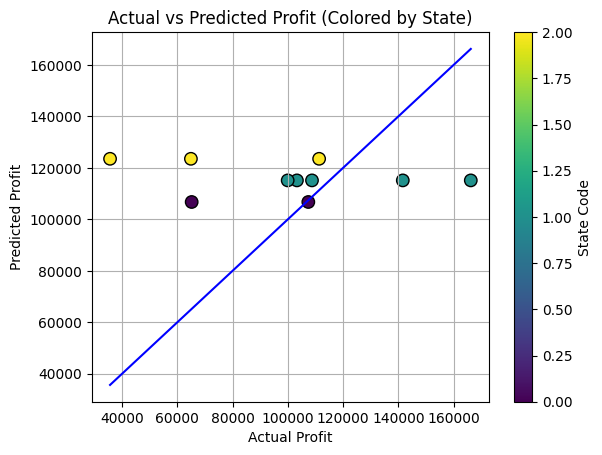

In [34]:
plt.scatter(y_test, y_pred, c=x_test['State'], cmap='viridis', s=80, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="blue")  # Perfect prediction line
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit (Colored by State)")
plt.grid(True)
plt.colorbar(label="State Code")
plt.show()
